# YOLOv7 Pothole Detection

## Repro [YOLOv7](https://github.com/WongKinYiu/yolov7.git)

In [1]:
!git clone https://github.com/rkuo2000/yolov7
%cd yolov7

Cloning into 'yolov7'...
remote: Enumerating objects: 679, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 679 (delta 12), reused 0 (delta 0), pack-reused 647
Receiving objects: 100% (679/679), 75.32 MiB | 43.90 MiB/s, done.
Resolving deltas: 100% (326/326), done.
/kaggle/working/yolov7


In [2]:
!pip install -r requirements.txt
!pip uninstall wandb -y

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 80.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf 23.8.0 requires cubinlinker, which is not installed.
cudf 23.8.0 requires cupy-cuda11x>=12.0.0, which is not installed.
cudf 23.8.0 requires ptxcompiler, which is not installed.
cuml 23.8.0 requires cupy-cuda11x>=12.0.0, which is not installed.
dask-cudf 23.8.0 requires cupy-cuda11x>=12.0.0, which is not installed.
keras-nlp 0.9.3 requires keras-core, which is not installed.
tensorflow-decision-forests 1.8.1 requires wurlitzer, which is not installed.
albumentations 1.4.0 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
apache-beam 2.46.0 requires dill<0.3.2,>

In [3]:
import os
import glob as glob
import matplotlib.pyplot as plt
import random
import cv2

## Download and Extract the Dataset

In [4]:
# Download the dataset.
#!wget https://learnopencv.s3.us-west-2.amazonaws.com/pothole_dataset.zip 
# Extract the dataset.
#!unzip -q pothole_dataset.zip

In [5]:
!mkdir -p Datasets
!cp -rf /kaggle/input/pothole Datasets

## Visualize Images from the Dataset

In [6]:
# Function to convert bounding boxes in YOLO format to xmin, ymin, xmax, ymax.
def yolo2bbox(bboxes):
    xmin, ymin = bboxes[0]-bboxes[2]/2, bboxes[1]-bboxes[3]/2
    xmax, ymax = bboxes[0]+bboxes[2]/2, bboxes[1]+bboxes[3]/2
    return xmin, ymin, xmax, ymax

In [7]:
def plot_box(image, bboxes, labels):
    # Need the image height and width to denormalize
    # the bounding box coordinates
    h, w, _ = image.shape
    for box_num, box in enumerate(bboxes):
        x1, y1, x2, y2 = yolo2bbox(box)
        # Denormalize the coordinates.
        xmin = int(x1*w)
        ymin = int(y1*h)
        xmax = int(x2*w)
        ymax = int(y2*h)

        thickness = max(2, int(w/275))
                
        cv2.rectangle(
            image, 
            (xmin, ymin), (xmax, ymax),
            color=(0, 0, 255),
            thickness=thickness
        )
    return image

In [8]:
# Function to plot images with the bounding boxes.
def plot(image_paths, label_paths, num_samples):
    all_images = []
    all_images.extend(glob.glob(image_paths+'/*.jpg'))
    all_images.extend(glob.glob(image_paths+'/*.JPG'))
    all_labels = glob.glob(label_paths)
    
    all_images.sort()
    all_labels.sort()

    num_images = len(all_images)
    
    plt.figure(figsize=(15, 12))
    for i in range(num_samples):
        j = random.randint(0,num_images-1)
        image = cv2.imread(all_images[j])
        with open(all_labels[j], 'r') as f:
            bboxes = []
            labels = []
            label_lines = f.readlines()
            for label_line in label_lines:
                label = label_line[0]
                bbox_string = label_line[2:]
                x_c, y_c, w, h = bbox_string.split(' ')
                x_c = float(x_c)
                y_c = float(y_c)
                w = float(w)
                h = float(h)
                bboxes.append([x_c, y_c, w, h])
                labels.append(label)
        result_image = plot_box(image, bboxes, labels)
        plt.subplot(2, 2, i+1)
        plt.imshow(result_image[:, :, ::-1])
        plt.axis('off')
    plt.subplots_adjust(wspace=1)
    plt.tight_layout()
    plt.show()

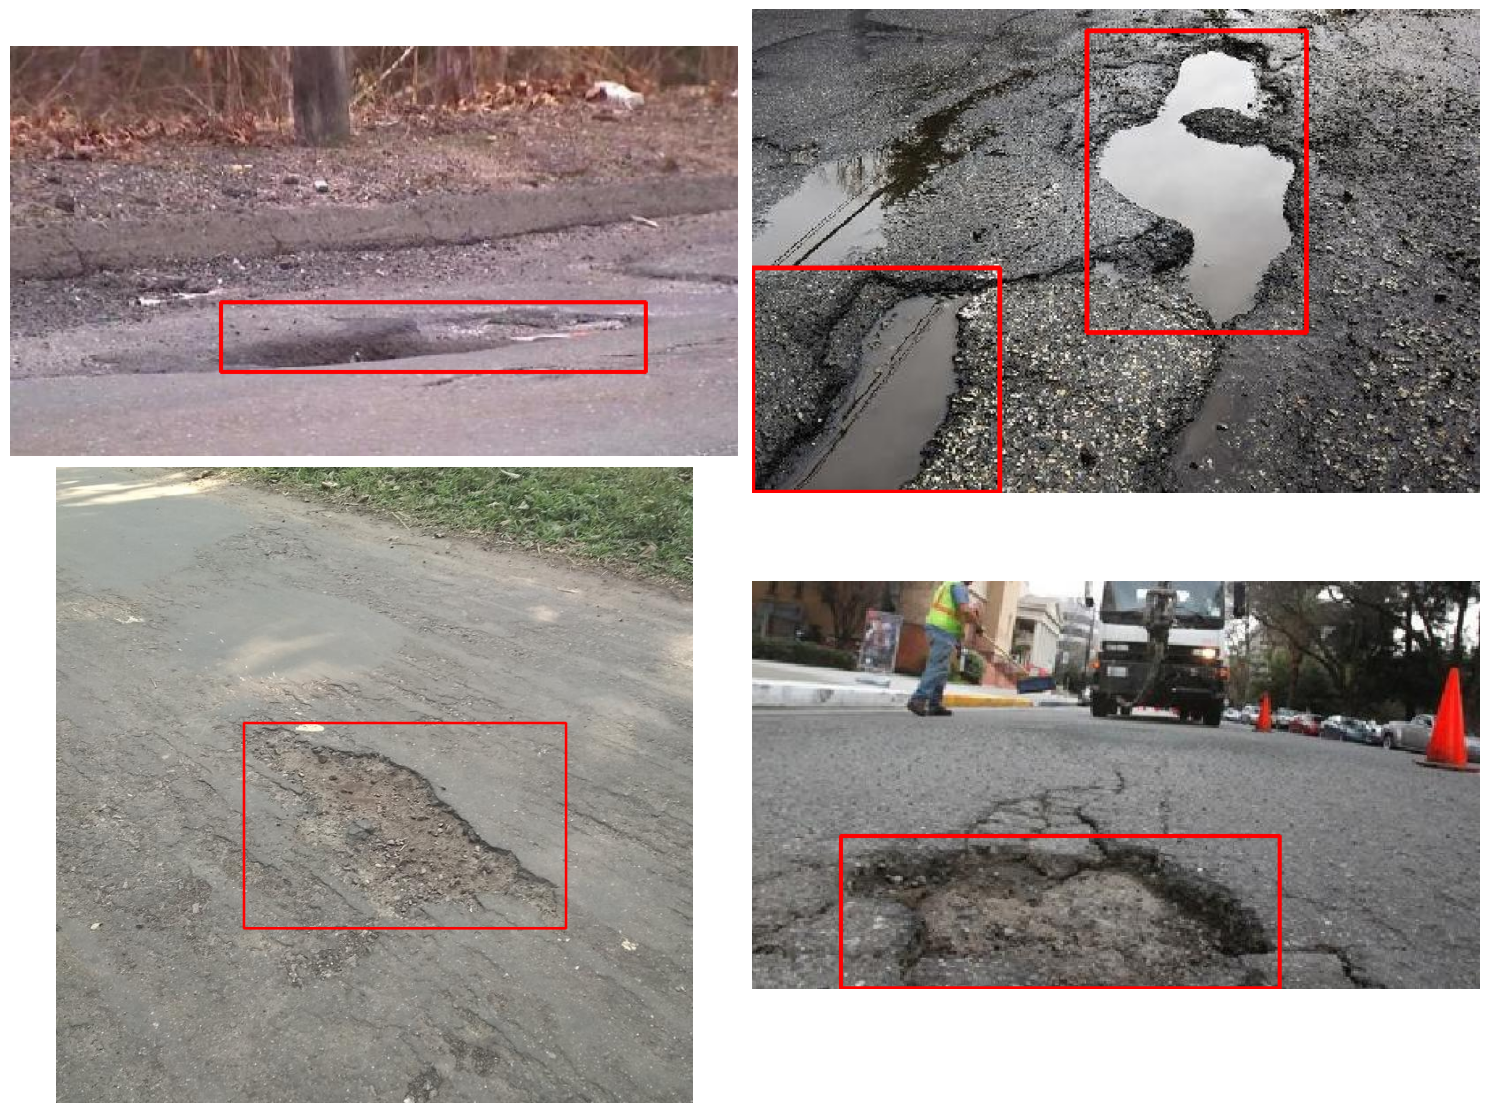

In [9]:
# Visualize a few training images.
plot(
    image_paths='./Datasets/pothole/train/images', 
    label_paths='./Datasets/pothole/train/labels/*.txt',
    num_samples=4,
)

## Create the Data YAML File

In [10]:
%%writefile data/pothole.yaml
train: ./Datasets/pothole/train/images
val:  ./Datasets/pothole/valid/images
test: ./Datasets/pothole/test/images

# Classes
nc: 1  # number of classes
names: ['pothole']  # class names

Overwriting data/pothole.yaml


## YOLOv7 Tiny Model Fixed Resolution Training

In [11]:
!sed -i "s/nc: 80/nc: 1/" cfg/training/yolov7-tiny.yaml
!sed -i "s/IDetect/Detect/" cfg/training/yolov7-tiny.yaml

## Train Model

In [12]:
!python train.py --epochs 100 --workers 4 --device 0 --batch-size 32 \
--data data/pothole.yaml --img 640 640 --cfg cfg/training/yolov7-tiny.yaml \
--weights 'weights/yolov7-tiny.pt' --name exp --hyp data/hyp.scratch.tiny.yaml

2024-05-12 20:28:22.436165: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-12 20:28:22.436268: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-12 20:28:22.578469: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
wandb: Install Weights & Biases for YOLOR logging with 'pip install wandb' (recommended)
/opt/conda/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /usr/local/src/pytorch/aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.me

## Test Model

In [13]:
!python test.py --weights runs/train/exp/weights/best.pt --task test --data data/pothole.yaml

Namespace(weights=['runs/train/exp/weights/best.pt'], data='data/pothole.yaml', batch_size=32, img_size=640, conf_thres=0.001, iou_thres=0.65, task='test', device='', single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project='runs/test', name='exp', exist_ok=False, no_trace=False, v5_metric=False)
Fusing layers... 
/opt/conda/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /usr/local/src/pytorch/aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
 Convert model to Traced-model... 
 traced_script_module saved! 
 model is traced! 

test: Scanning 'Datasets/pothole/test/labels' images and labels... 67 found, 0 m
               Class      Images      Labels           P           R      mAP@.5
                 all          67     

## Inference

In [14]:
!cp /kaggle/input/pothole/test/images/img-105_jpg.rf.3fe9dff3d1631e79ecb480ff403bcb86.jpg test.jpg
!python detect.py --weights runs/train/exp/weights/best.pt --conf 0.25 --img-size 640 --source test.jpg

Namespace(weights=['runs/train/exp/weights/best.pt'], source='test.jpg', img_size=640, conf_thres=0.25, iou_thres=0.45, device='', view_img=False, save_txt=False, save_conf=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project='runs/detect', name='exp', exist_ok=False, no_trace=False)
Fusing layers... 
/opt/conda/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /usr/local/src/pytorch/aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
 Convert model to Traced-model... 
 traced_script_module saved! 
 model is traced! 

2 potholes, Done. (5.2ms) Inference, (421.1ms) NMS
 The image with the result is saved in: runs/detect/exp/test.jpg
Done. (0.514s)


## Show Result

In [15]:
from IPython.display import Image

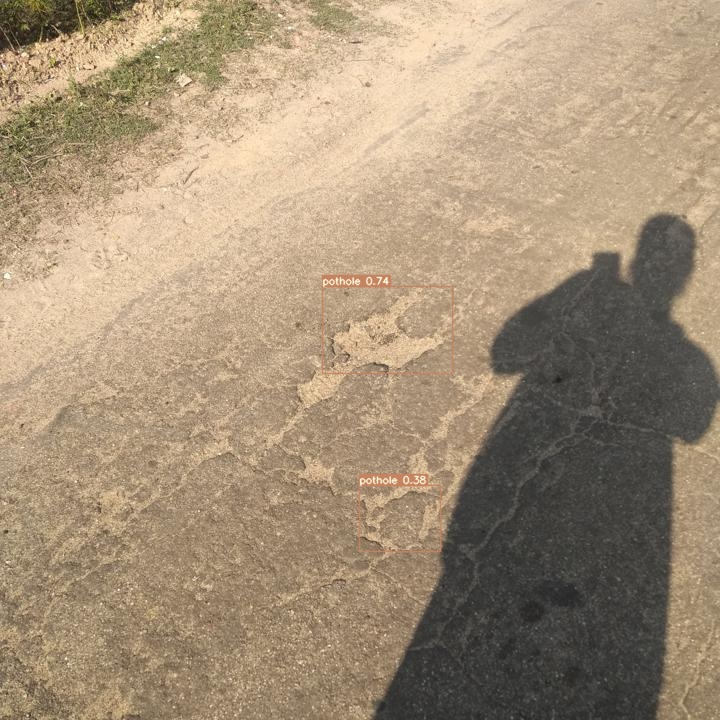

In [16]:
Image(filename='runs/detect/exp/test.jpg')